In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv('C:/Users/raiss/Downloads/new_data.csv')

In [3]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [15]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [16]:
obj = (data.dtypes == 'object')
obj_cols = list(obj[obj].index)
print("Categorical variables:", len(obj_cols))


num_cols = data.select_dtypes(include=['int']).columns.tolist()
print("Integer variables:", len(num_cols))

fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:", len(fl_cols))

Categorical variables: 3
Integer variables: 3
Float variables: 5


Text(0.5, 0, 'Type of Transaction')

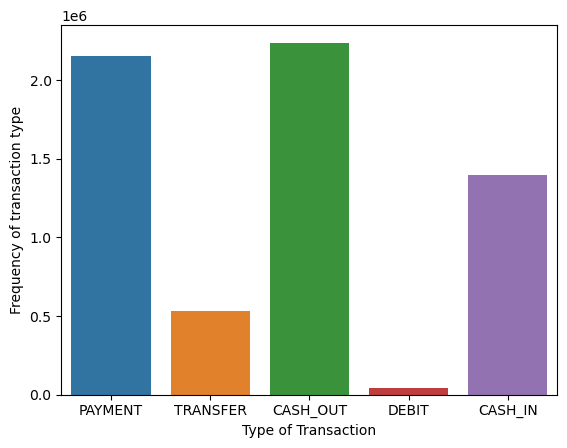

In [17]:
ax=sns.countplot(x='type', data=data)
ax.set_ylabel('Frequency of transaction type')
ax.set_xlabel('Type of Transaction')

In [18]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


<Axes: xlabel='type', ylabel='amount'>

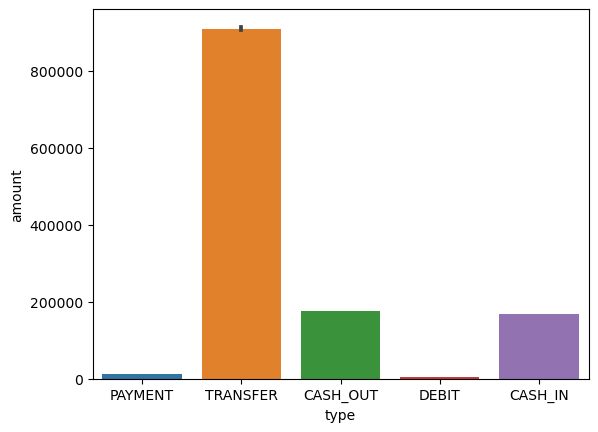

In [3]:
sns.barplot(x='type', y='amount', data=data)

In [4]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

C:\Users\raiss\AppData\Local\Temp\ipykernel_16328\3316386212.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['step'], bins=50)


<Axes: xlabel='step', ylabel='Density'>

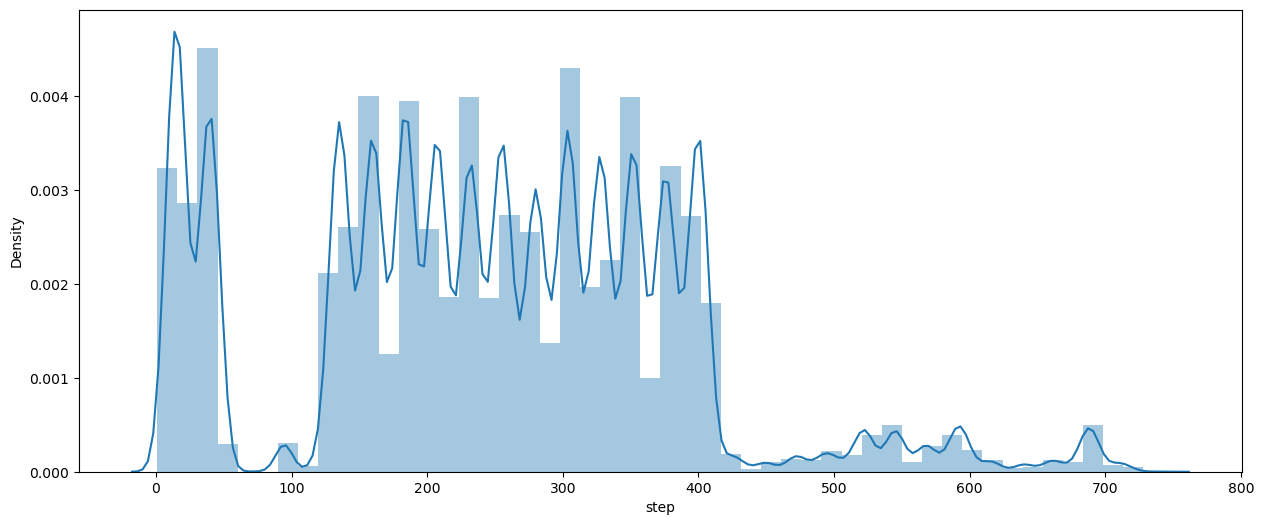

In [5]:
plt.figure(figsize=(15,6))
sns.distplot(data['step'], bins=50)

<Axes: >

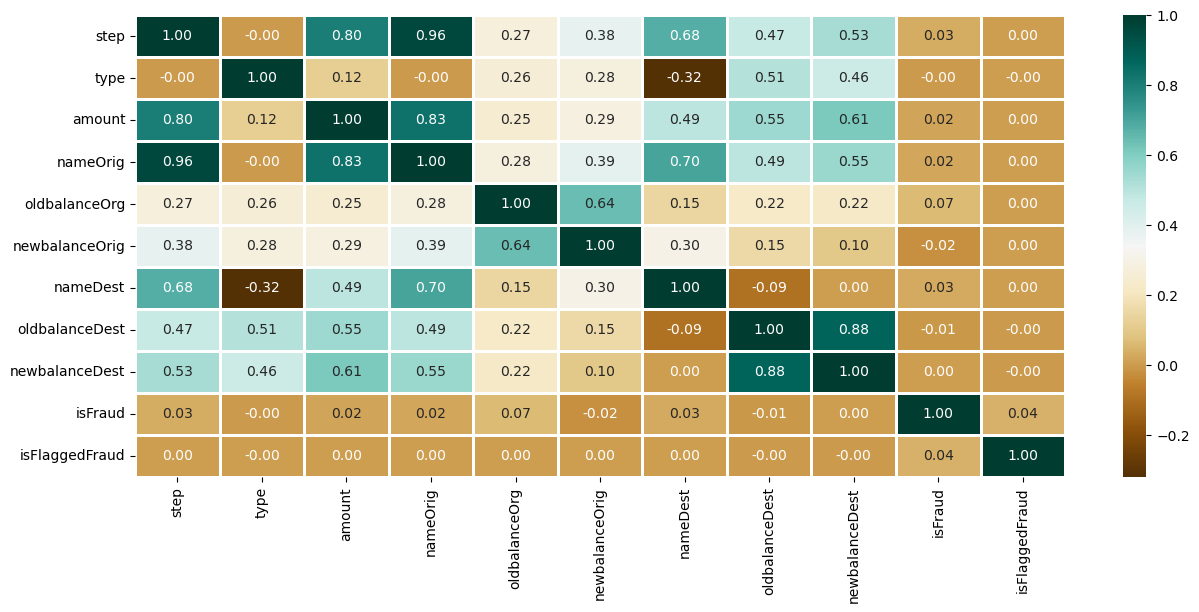

In [6]:
plt.figure(figsize=(15,6))
sns.heatmap(data.apply(lambda x: pd.factorize(x)[0]).corr(),
           cmap='BrBG',
           fmt='.2f',
           linewidths=2,
           annot=True)

In [7]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [8]:
type_new = pd.get_dummies(data['type'],drop_first=True)

In [9]:
data_new = pd.concat([data, type_new], axis=1)

In [10]:
data_new.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,False,False,True,False


In [11]:
x = data_new.drop(['isFraud', 'nameOrig', 'nameDest', 'type'], axis=1)
y = data_new['isFraud']

In [12]:
x


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False
2,1,181.00,181.00,0.00,0.00,0.00,0,False,False,False,True
3,1,181.00,181.00,0.00,21182.00,0.00,0,True,False,False,False
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,0,True,False,False,False
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,0,False,False,False,True
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,0,True,False,False,False
6362618,743,850002.52,850002.52,0.00,0.00,0.00,0,False,False,False,True


In [13]:
x.shape, y.shape

((6362620, 11), (6362620,))

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size = 0.3, random_state = 42)


In [15]:
!pip install xgboost

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [20]:
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "Random Forest": RandomForestClassifier(n_estimators=7,
                                            criterion='entropy',
                                            random_state=7,
                                            n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(x_train, y_train)

    # Training predictions
    train_preds = model.predict_proba(x_train)[:, 1]
    train_auc = ras(y_train, train_preds)

    # Validation predictions
    test_preds = model.predict_proba(x_test)[:, 1]
    test_auc = ras(y_test, test_preds)

    results.append([name, train_auc, test_auc])


    

C:\Users\raiss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\raiss\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:56:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
# Convert results into a DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Train ROC-AUC", "Validation ROC-AUC"])
print(results_df)


                 Model  Train ROC-AUC  Validation ROC-AUC
0  Logistic Regression       0.887683            0.885272
1              XGBoost       0.707836            0.712453
2        Random Forest       0.999999            0.963572


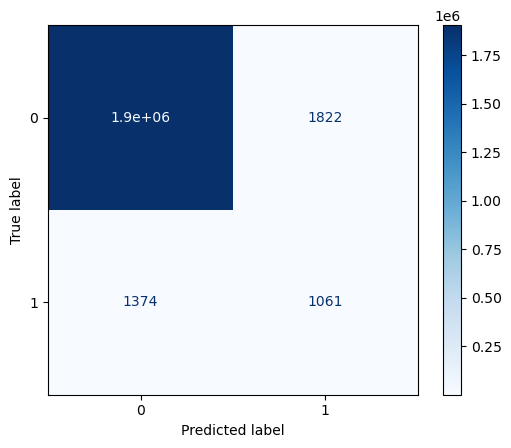

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models["Logistic Regression"], x_test, y_test, cmap="Blues" )
plt.show()



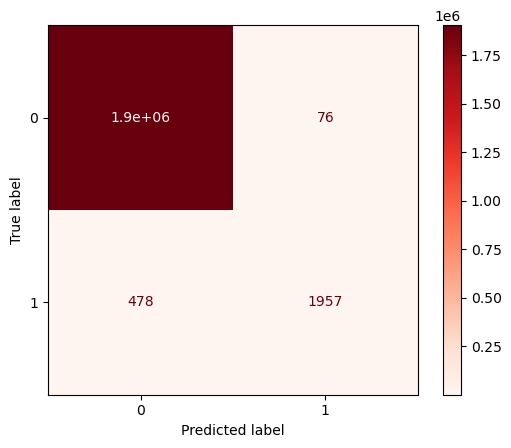

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models["Random Forest"], x_test, y_test, cmap="Reds")
plt.show()



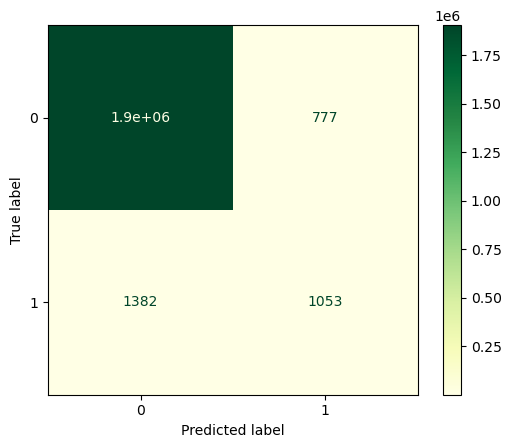

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models["XGBoost"], x_test, y_test, cmap="YlGn")

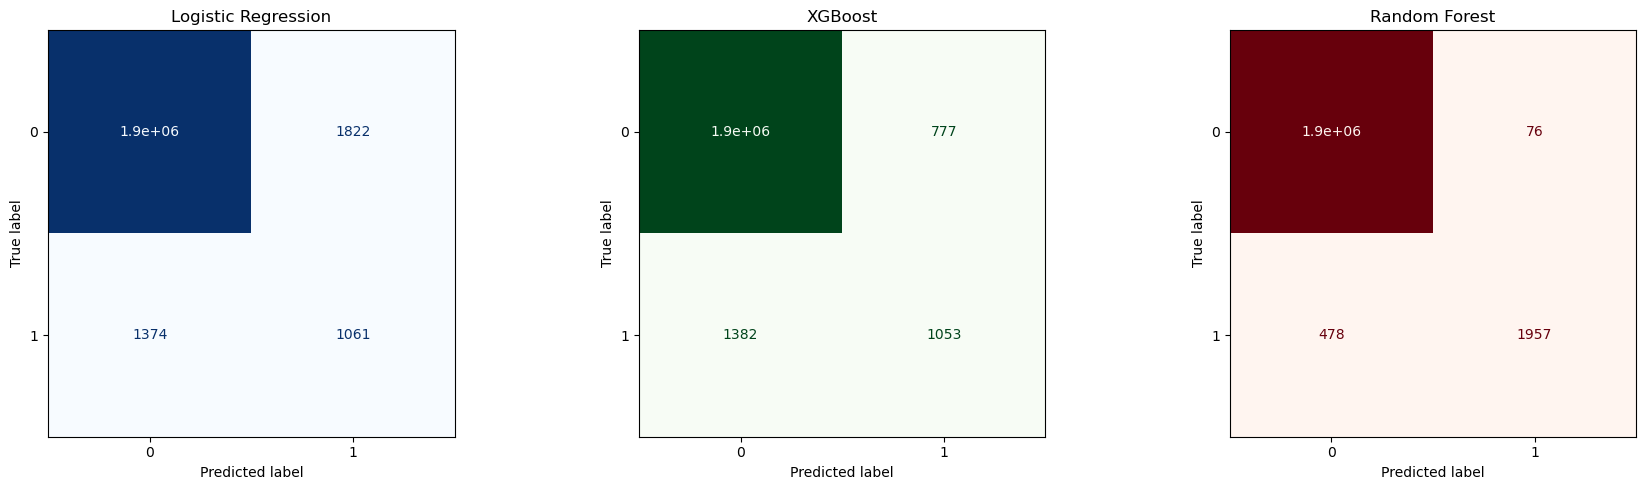


===== Summary Table =====

+---------------------+------------+-------------+----------+------------+
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |
+=====================+============+=============+==========+============+
| Logistic Regression |   0.998326 |    0.368019 | 0.435729 |   0.399022 |
+---------------------+------------+-------------+----------+------------+
| XGBoost             |   0.998869 |    0.57541  | 0.432444 |   0.493787 |
+---------------------+------------+-------------+----------+------------+
| Random Forest       |   0.99971  |    0.962617 | 0.803696 |   0.876007 |
+---------------------+------------+-------------+----------+------------+


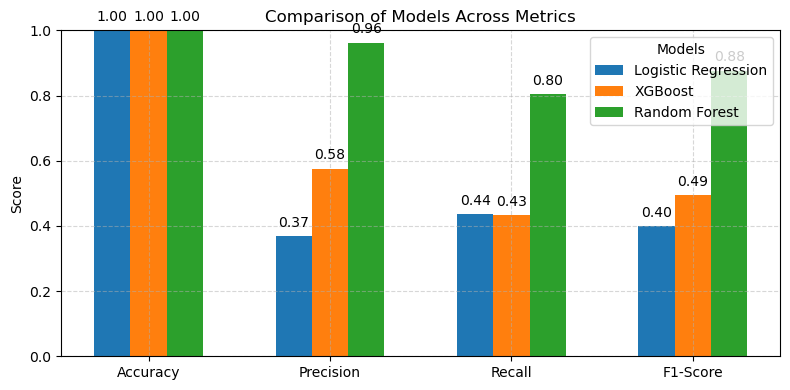

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, ConfusionMatrixDisplay
)
import numpy as np

# Store metrics
results = []

# Colors for each model
colors = ["Blues", "Greens", "Reds"]

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model), color in zip(axes, models.items(), colors):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, accuracy, precision, recall, f1])
    
    # Plot confusion matrix with its unique color
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=color, ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Convert results into DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
from tabulate import tabulate

print("\n===== Summary Table =====\n")
print(tabulate(results_df, headers="keys", tablefmt="grid", showindex=False))


# Bar chart: metrics on x-axis, models as bars
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))  # positions for metrics
width = 0.2  # width of each bar

fig, ax = plt.subplots(figsize=(8,4))

for i, model_name in enumerate(results_df["Model"]):
    ax.bar(x + i*width - width, results_df.loc[i, metrics], width, label=model_name)

# Labels, title, ticks, legend
ax.set_ylabel('Score')
ax.set_title('Comparison of Models Across Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend(title="Models")
ax.grid(True, linestyle='--', alpha=0.5)

# Show values on top of bars
for i, model_name in enumerate(results_df["Model"]):
    for j, metric in enumerate(metrics):
        value = results_df.loc[i, metric]
        ax.text(j + i*width - width, value + 0.02, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()
